In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('crime_data_clean.csv')
df.head()

,city,title,text,crime_category,total_victims,murder_reason,murder_child_victims,murder_male_adult_victims,murder_female_adult_victims,kidnap_child_victims,kidnap_male_adult_victims,kidnap_female_adult_victims,crime_against_women_type,total_adult_victims,total_child_victims
0,Ghaziabad,"Minor molests mute girl, sent to observation home",GHAZIABAD: A 12-year-old boy was sent to an ob...,Crime Against Women,3,Not Applicable,0,0,0,0,0,0,"8,10",0,3
1,Ghaziabad,Family out to buy car robbed of Rs 1 lakh by b...,GHAZIABAD: A family that had visited an automo...,Unclassified,0,Not Applicable,0,0,0,0,0,0,Not Applicable,0,0
2,Ghaziabad,"This gang posed as cops to extort youths, couples",GHAZIABAD: Five persons were arrested on Monda...,Unclassified,0,Not Applicable,0,0,0,0,0,0,Not Applicable,0,0
3,Ghaziabad,"Residents object to loud music, thrashed in Gh...","Ghaziabad: Four tenants, including two soldier...",Unclassified,0,Not Applicable,0,0,0,0,0,0,Not Applicable,0,0
4,Ghaziabad,Man kills self after being refused money for d...,GHAZIABAD: A 25-year-old allegedly committed s...,Unclassified,0,Not Applicable,0,0,0,0,0,0,Not Applicable,0,0


In [2]:
pd.crosstab

<function pandas.core.reshape.pivot.crosstab(index, columns, values=None, rownames=None, colnames=None, aggfunc=None, margins: 'bool' = False, margins_name: 'Hashable' = 'All', dropna: 'bool' = True, normalize: "bool | Literal[0, 1, 'all', 'index', 'columns']" = False) -> 'DataFrame'>

In [3]:
import os 
print(os.getcwd)

<built-in function getcwd>


In [4]:
pd.crosstab(df['city'], df['crime_category'])


crime_category,Crime Against Women,Kidnapping,Murder,Unclassified
city,,,,
Ghaziabad,68,11,47,41
Kanpur,46,2,37,12
Lucknow,81,5,63,53


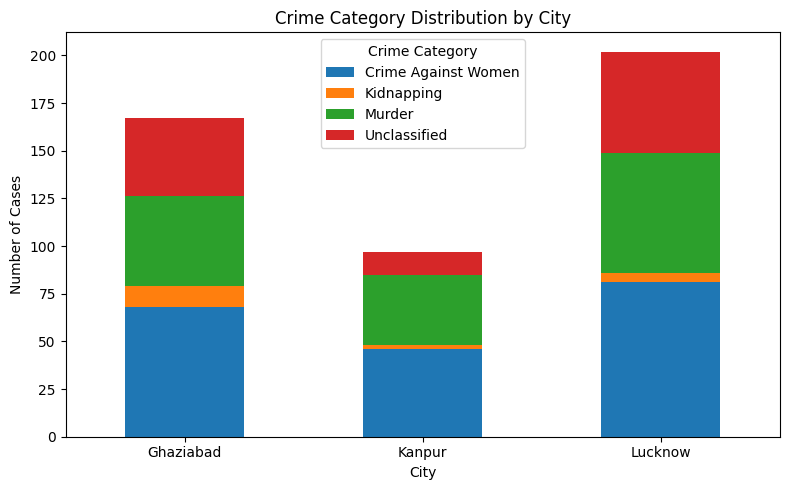

In [5]:
pd.crosstab(df['city'], df['crime_category']).plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Crime Category Distribution by City')
plt.ylabel('Number of Cases')
plt.xlabel('City')
plt.xticks(rotation=0)
plt.legend(title='Crime Category')
plt.tight_layout()
plt.show()

In [6]:
victim_totals = {
    'Child Victims (Murder)': df['murder_child_victims'].sum(),
    'Male Adult Victims (Murder)': df['murder_male_adult_victims'].sum(),
    'Female Adult Victims (Murder)': df['murder_female_adult_victims'].sum(),
    'Child Victims (Kidnapping)': df['kidnap_child_victims'].sum(),
    'Male Adult Victims (Kidnapping)': df['kidnap_male_adult_victims'].sum(),
    'Female Adult Victims (Kidnapping)': df['kidnap_female_adult_victims'].sum(),
}

victim_totals

{'Child Victims (Murder)': np.int64(19),
 'Male Adult Victims (Murder)': np.int64(103),
 'Female Adult Victims (Murder)': np.int64(52),
 'Child Victims (Kidnapping)': np.int64(13),
 'Male Adult Victims (Kidnapping)': np.int64(10),
 'Female Adult Victims (Kidnapping)': np.int64(3)}

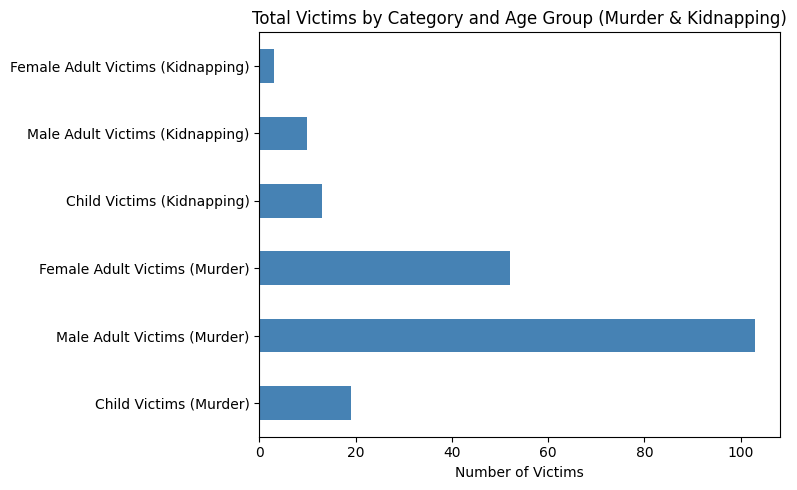

In [7]:
victim_series = pd.Series(victim_totals)
victim_series.plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Total Victims by Category and Age Group (Murder & Kidnapping)')
plt.xlabel('Number of Victims')
plt.tight_layout()
plt.show()

In [8]:
murder_df = df[df['murder_reason'] != 'Not Applicable']
murder_df['murder_reason'].value_counts()

murder_reason
Unknown/Other        40
Love Affairs         30
Petty Quarrels       19
Family Dispute       16
Personal Vendetta    16
Money Disputes       14
Property Disputes    10
Casteism              2
Name: count, dtype: int64

In [9]:
df['murder_reason'].unique()

array(['Not Applicable', 'Money Disputes', 'Love Affairs',
       'Unknown/Other', 'Petty Quarrels', 'Property Disputes',
       'Family Dispute', 'Personal Vendetta', 'Casteism'], dtype=object)

In [10]:
df['murder_reason'] = df['murder_reason'].replace({
    'Unknown/Other': 'Unknown/other',
    'Property Disputes': 'Property/Land Disputes'
})

df['murder_reason'].unique()

array(['Not Applicable', 'Money Disputes', 'Love Affairs',
       'Unknown/other', 'Petty Quarrels', 'Property/Land Disputes',
       'Family Dispute', 'Personal Vendetta', 'Casteism'], dtype=object)

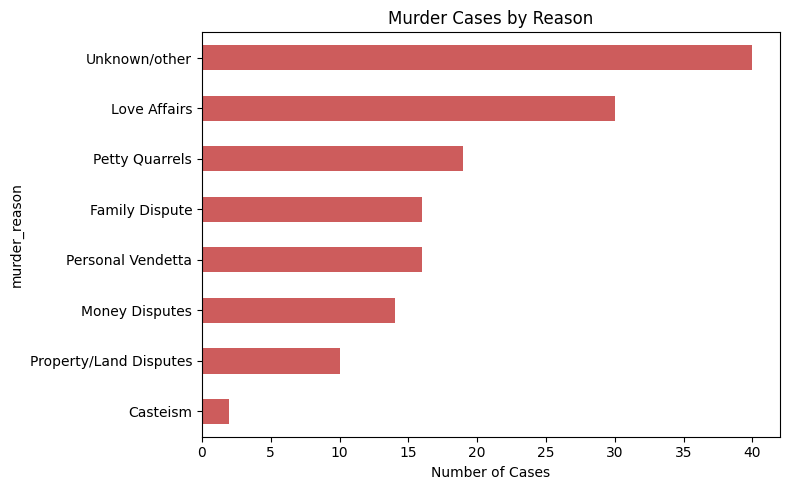

In [11]:
murder_df = df[df['murder_reason'] != 'Not Applicable']

murder_df['murder_reason'].value_counts().plot(kind='barh', figsize=(8,5), color='indianred')
plt.title('Murder Cases by Reason')
plt.xlabel('Number of Cases')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
caw_df = df[df['crime_against_women_type'] != 'Not Applicable'].copy()

caw_exploded = caw_df['crime_against_women_type'].str.split(',').explode()
caw_exploded.value_counts()

crime_against_women_type
8                     63
7                     55
10                    49
3                     25
6                     22
2                     19
1                     19
9                     10
4                      7
5                      3
Other/Undocumented     3
Name: count, dtype: int64

In [13]:
crime_against_women_legend = {
    '1': 'Murder with Rape',
    '2': 'Dowry Deaths (Sec. 304B)',
    '3': 'Suicide (Sec. 305/306)',
    '4': 'Kidnapping (All)',
    '5': 'Acid Attack (Sec. 326A IPC)',
    '6': 'Cruelty by Husband/in-laws (Sec. 498A IPC)',
    '7': 'Rape only (Sec. 376 or 511 IPC)',
    '8': 'Assault on Women - Outrage Modesty (Sec. 354 IPC)',
    '9': 'Cyber Crimes against Women',
    '10': 'POCSO (Protection of Children from Sexual Offences)',
    'Other/Undocumented': 'Other/Undocumented',
}

caw_counts = caw_exploded.value_counts()
caw_counts.index = caw_counts.index.map(crime_against_women_legend)
caw_counts

crime_against_women_type
Assault on Women - Outrage Modesty (Sec. 354 IPC)      63
Rape only (Sec. 376 or 511 IPC)                        55
POCSO (Protection of Children from Sexual Offences)    49
Suicide (Sec. 305/306)                                 25
Cruelty by Husband/in-laws (Sec. 498A IPC)             22
Dowry Deaths (Sec. 304B)                               19
Murder with Rape                                       19
Cyber Crimes against Women                             10
Kidnapping (All)                                        7
Acid Attack (Sec. 326A IPC)                             3
Other/Undocumented                                      3
Name: count, dtype: int64

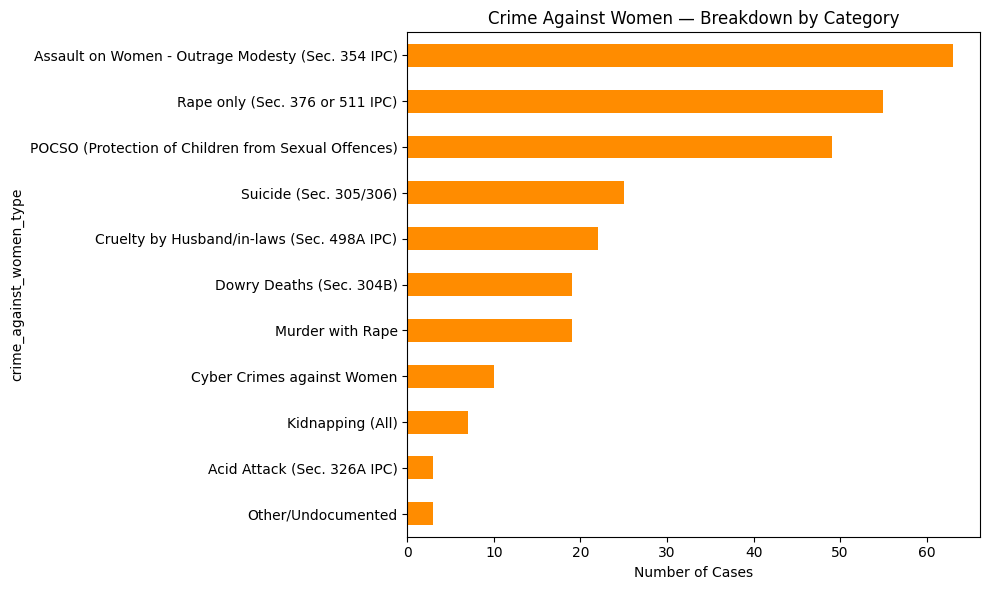

In [14]:
caw_counts.sort_values().plot(kind='barh', figsize=(10,6), color='darkorange')
plt.title('Crime Against Women — Breakdown by Category')
plt.xlabel('Number of Cases')
plt.tight_layout()
plt.show()

In [15]:
caw_df['crime_against_women_type_split'] = caw_df['crime_against_women_type'].str.split(',')
caw_city_exploded = caw_df.explode('crime_against_women_type_split')[['city', 'crime_against_women_type_split']]
caw_city_exploded['crime_against_women_type_split'] = caw_city_exploded['crime_against_women_type_split'].map(crime_against_women_legend)

pd.crosstab(caw_city_exploded['crime_against_women_type_split'], caw_city_exploded['city'])

city,Ghaziabad,Kanpur,Lucknow
crime_against_women_type_split,,,
Acid Attack (Sec. 326A IPC),2,1,0
Assault on Women - Outrage Modesty (Sec. 354 IPC),17,8,38
Cruelty by Husband/in-laws (Sec. 498A IPC),10,3,9
Cyber Crimes against Women,4,2,4
Dowry Deaths (Sec. 304B),14,4,1
Kidnapping (All),3,1,3
Murder with Rape,4,7,8
Other/Undocumented,1,2,0
POCSO (Protection of Children from Sexual Offences),16,19,14


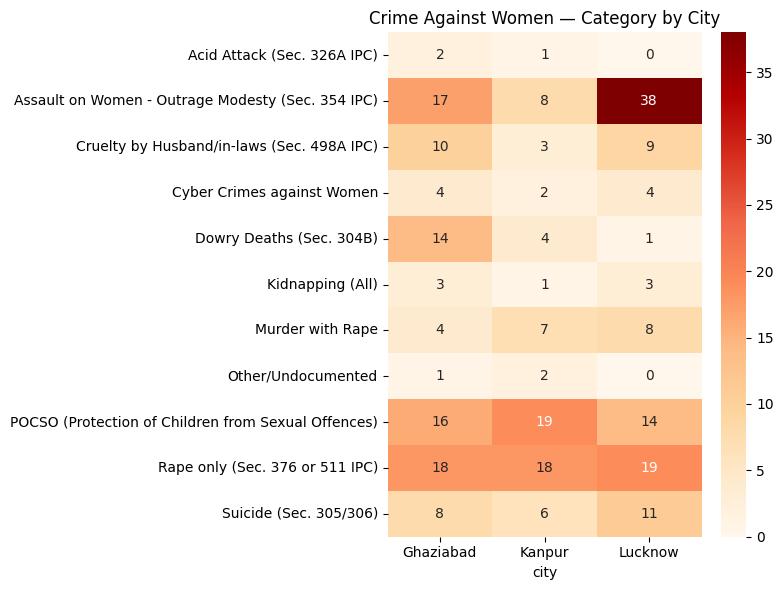

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(pd.crosstab(caw_city_exploded['crime_against_women_type_split'], caw_city_exploded['city']),
            annot=True, fmt='d', cmap='OrRd')
plt.title('Crime Against Women — Category by City')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [17]:
df['total_victims'].describe()

count    466.000000
mean       0.894850
std        0.808354
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       10.000000
Name: total_victims, dtype: float64

In [18]:
df[df['total_victims'] >= 5][['city', 'title', 'crime_category', 'total_victims']]

,city,title,crime_category,total_victims
184,Kanpur,Five suffer burns in acid attack by neighbour,Crime Against Women,5
219,Kanpur,5 hammered to death in Hamirpur,Murder,5
401,Lucknow,"10 die, 20 hurt, 5 held as UP gang goes on sho...",Murder,10
459,Lucknow,"'Sex maniac' held in Azamgarh for rape, triple...",Murder,5


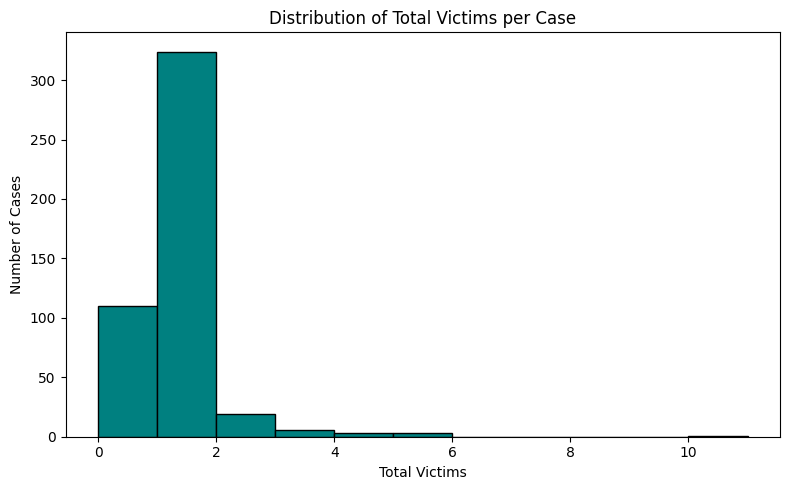

In [19]:
df['total_victims'].plot(kind='hist', bins=range(0, 12), figsize=(8,5), color='teal', edgecolor='black')
plt.title('Distribution of Total Victims per Case')
plt.xlabel('Total Victims')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.show()

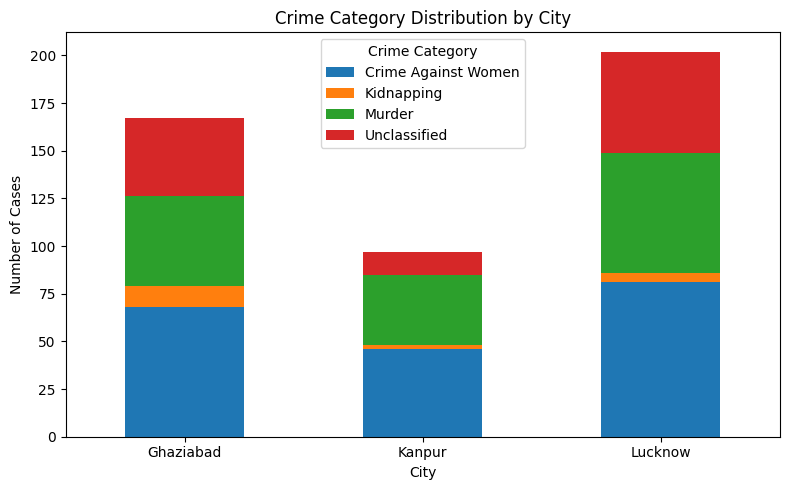

In [20]:
import os
os.makedirs('figures', exist_ok=True)

# Re-save key charts as PNG files for your README/report
pd.crosstab(df['city'], df['crime_category']).plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Crime Category Distribution by City')
plt.ylabel('Number of Cases')
plt.xlabel('City')
plt.xticks(rotation=0)
plt.legend(title='Crime Category')
plt.tight_layout()
plt.savefig('figures/crime_by_city.png', dpi=150)
plt.show()

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
